# Academic Success Classifier

## Problem Statement
Predict whether a student will Graduate, Enroll, or Drop Out using academic and demographic data.

## Objectives
- Identify key factors influencing student success
- Build a predictive classification model
- Provide actionable recommendations for at-risk students

## Business Context

Student dropout is a major challenge in higher education.

By predicting student outcomes early, institutions can:
- Provide targeted support
- Improve retention rates
- Optimize resource allocation

This project aims to simulate a real-world predictive system for academic success monitoring.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [2]:
# Load the dataset
df = pd.read_csv('data/data.csv', sep=';')
df.columns = df.columns.str.strip()

df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
# Data exploration
df.shape
df['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

## Data Overview

- The dataset contains student academic, demographic, and economic features.
- Target variable represents final student outcome:
  - Graduate    2209
  - Enrolled     794    
  - Dropout     1421

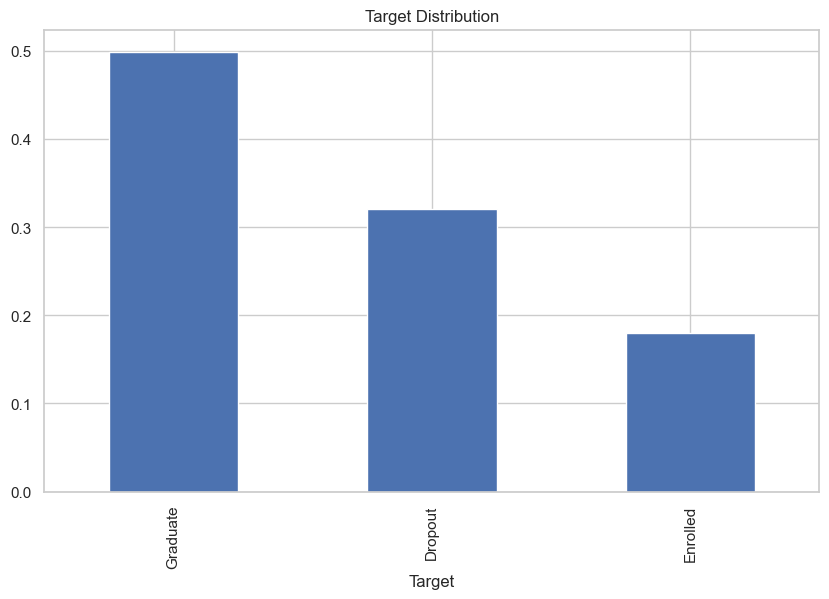

In [4]:
# Visualize the target distribution
df['Target'].value_counts(normalize=True).plot(kind='bar')
plt.title("Target Distribution")
plt.show()

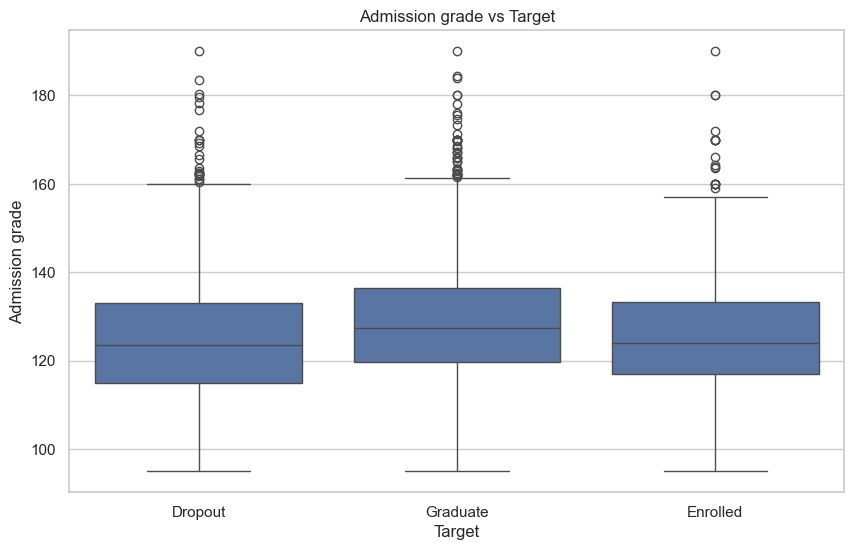

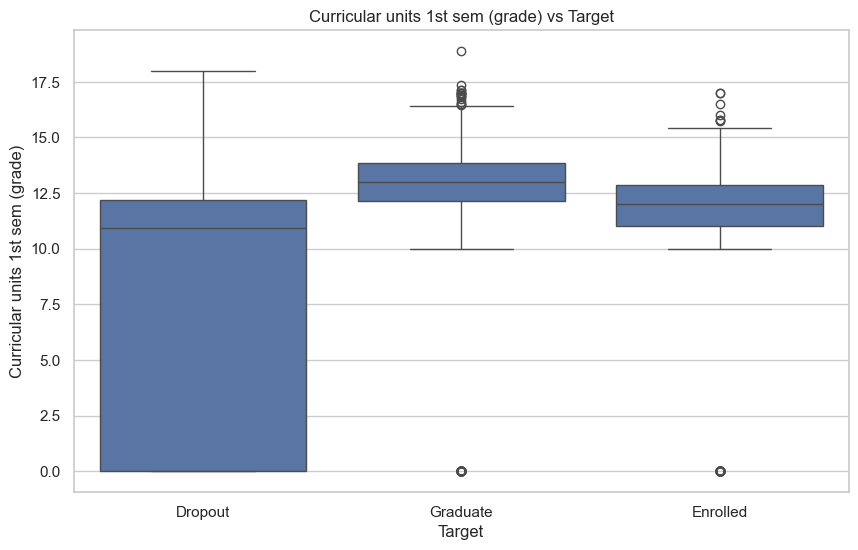

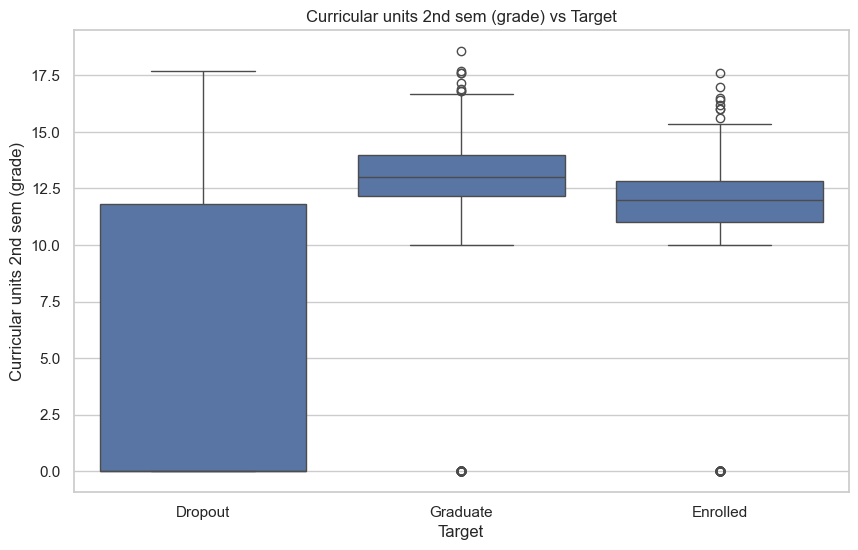

In [5]:
# Visualize feature distributions by target class
features = [
    'Admission grade',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)'
]

for col in features:
    plt.figure()
    sns.boxplot(x='Target', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

## EDA Insights

- Students who graduate tend to have higher academic performance across semesters.
- Dropout students consistently show lower grades.
- Academic performance is strongly linked to final outcomes.

In [6]:
# Prepare the data for modeling
selected_features = [
    'Admission grade',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Age at enrollment',
    'Tuition fees up to date'
]

X = df[selected_features]
y = df['Target']

In [7]:
# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

le.classes_

array(['Dropout', 'Enrolled', 'Graduate'], dtype=object)

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
# Train a Gradient Boosting Classifier
model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

### Why Gradient Boosting?

Gradient Boosting was selected because:
- It captures non-linear relationships effectively
- Handles structured/tabular data well
- Provides feature importance insights

Compared to simpler models, it achieved better generalization and predictive performance on this dataset.

In [10]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

     Dropout       0.77      0.74      0.76       284
    Enrolled       0.50      0.32      0.39       159
    Graduate       0.78      0.91      0.84       442

    accuracy                           0.75       885
   macro avg       0.69      0.66      0.66       885
weighted avg       0.73      0.75      0.73       885



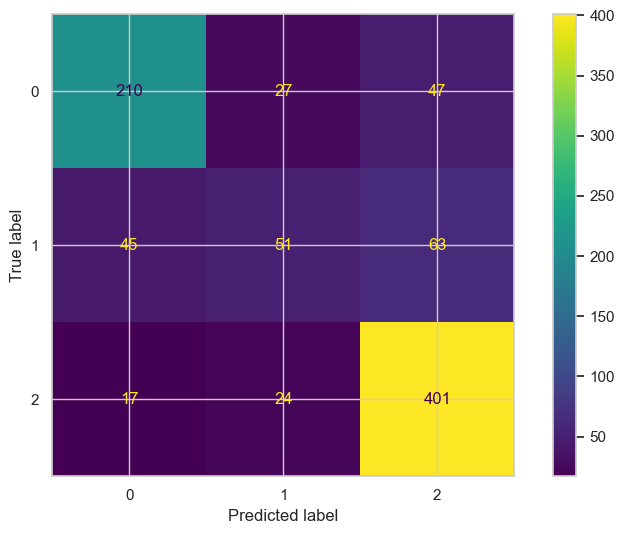

In [11]:
# Visualize the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

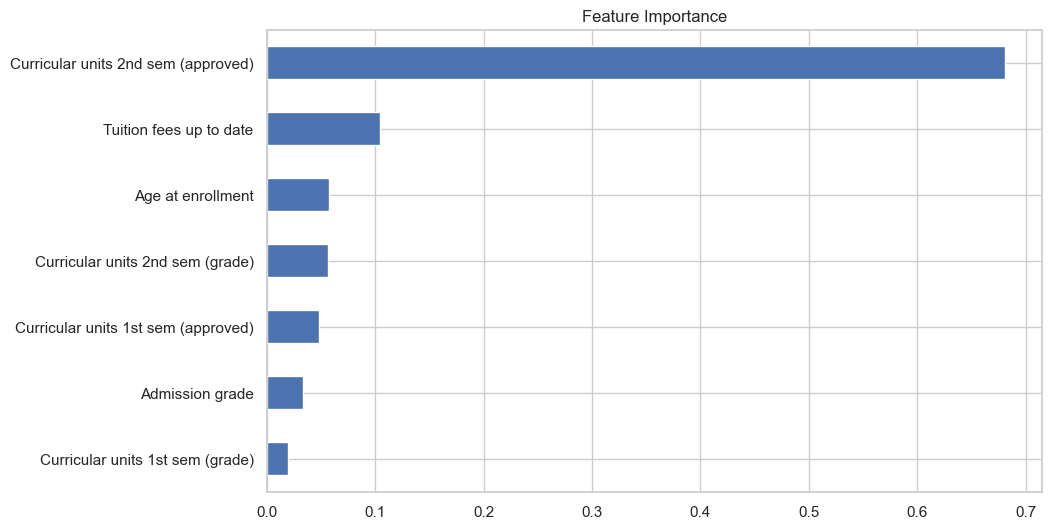

In [12]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

## Feature Importance Insights

- Academic performance metrics are the strongest predictors.
- Approved course units significantly influence outcomes.
- Financial status (tuition) also plays a role.

In [13]:
def generate_recommendation(row):
    issues = []

    if row['Curricular units 2nd sem (grade)'] < 10:
        issues.append("improve academic performance")

    if row['Tuition fees up to date'] == 0:
        issues.append("resolve financial constraints")

    if row['Curricular units 2nd sem (approved)'] < 3:
        issues.append("increase course completion")

    if not issues:
        return "Maintain current performance."

    return "Recommended actions: " + ", ".join(issues)

df['Recommendation'] = df.apply(generate_recommendation, axis=1)
df[['Target', 'Recommendation']].head()

,Target,Recommendation
0,Dropout,Recommended actions: improve academic performa...
1,Graduate,Recommended actions: resolve financial constra...
2,Dropout,Recommended actions: improve academic performa...
3,Graduate,Maintain current performance.
4,Graduate,Maintain current performance.


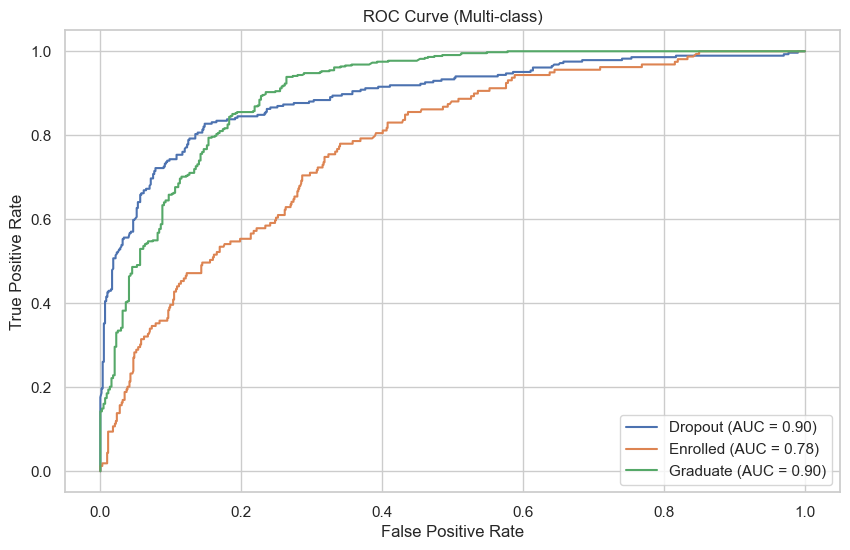

In [14]:
# ROC Curve for multi-class classification
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = model.predict_proba(X_test)

plt.figure()

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC = {auc(fpr, tpr):.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Multi-class)")
plt.legend()
plt.show()

## Model Evaluation Insights

- The model demonstrates strong predictive performance across all classes.
- ROC curves show good separation, indicating effective classification capability.
- The model performs best in identifying "Graduate" students, with slightly lower performance for "Enrolled".
- This aligns with the class imbalance observed during EDA.

## Conclusion

This project demonstrates how machine learning can predict student outcomes based on academic performance.

Key findings:
- Academic performance is the strongest predictor of success.
- Early intervention can help reduce dropout rates.
- Gradient Boosting provides reliable classification performance.

This system can be extended into a real-time academic monitoring tool.

## Limitations

- Model is trained on historical academic data only
- Does not account for real-time behavioral factors
- Performance may vary across institutions

## Future Improvements

- Incorporate time-series academic tracking
- Deploy as a web application (Streamlit)
- Integrate real-time student monitoring systems

In [15]:
!jupyter nbconvert --to html academic_success_classifier.ipynb

[NbConvertApp] Converting notebook academic_success_classifier.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 7 image(s).
[NbConvertApp] Writing 554559 bytes to academic_success_classifier.html
